In [67]:
import uproot
import awkward as ak
import numpy as np
import pandas as pd

run_number = 51

branch_list = [
    'Detector', 'Feb', 'Multiplicity', 'Channel',
    'Cell0TimeStamp', 'TimeInstant', 'TOTValue', 'PeakValue',
    'Baseline', 'Amplitude', 'ArraySize',
    'xCoord', 'yCoord', 'Davide', 'Golia', '7PAD', 'MCP',
]

branch_2d = [
    'Detector', 'Feb', 'Multiplicity', 'Channel',
    'Cell0TimeStamp', 'TimeInstant', 'TOTValue', 'PeakValue',
    'Baseline', 'Amplitude', 'xCoord', 'yCoord'
]

branch_1d = ['ArraySize', 'Davide', 'Golia', '7PAD', 'MCP']

chunks = []

with uproot.open(f"~/Scrivania/sampic_run{run_number}_merged.root") as file:
    tree = file["picoTree"]
    n_tot = tree.num_entries

    for i, chunk in enumerate(tree.iterate(branch_list, library="ak", step_size=50_000)):
        n_chunk = len(chunk)

        # ArraySize dice esattamente quante hit valide ci sono per evento
        array_size = ak.to_numpy(chunk['ArraySize'])  # shape (n_chunk,)

        # --- Branch 2D: taglia ogni riga a ArraySize invece di usare maschera -1 ---
        arr_2d = {k: ak.to_numpy(chunk[k]) for k in branch_2d}

        rows_2d = {k: [] for k in branch_2d}
        for evt in range(n_chunk):
            n_hit = array_size[evt]
            for k in branch_2d:
                rows_2d[k].append(arr_2d[k][evt, :n_hit])

        df_2d = pd.DataFrame({k: np.concatenate(rows_2d[k]) for k in branch_2d})

        # --- Branch 1D: ripeti per ogni hit dell'evento ---
        arr_1d = {k: ak.to_numpy(chunk[k]) for k in branch_1d}
        df_1d = pd.DataFrame({k: np.repeat(arr_1d[k], array_size) for k in branch_1d})


         # --- Waveform ---
        #waveform_raw = ak.to_numpy(chunk['Waveform'])
        #waveforms = []
        #for evt in range(n_chunk):
        #    n_hit = array_size[evt]
        #    for hit in range(n_hit):
        #        waveforms.append(waveform_raw[evt, hit, :])
        #df_2d['Waveform'] = waveforms
        





        # --- Multiplicity: estrai le 3 posizioni come colonne separate ---
        mult = ak.to_numpy(chunk['Multiplicity'])  # shape (n_chunk, 140)
        df_mult_per_evento = pd.DataFrame({
            'Mult_det0': mult[:, 0],
            'Mult_det1': mult[:, 1],
            'Mult_det2': mult[:, 2],
        })
        # Ripeti per ogni hit dell'evento
        df_mult = pd.DataFrame({
            col: np.repeat(df_mult_per_evento[col].values, array_size)
            for col in df_mult_per_evento.columns
        })

        # --- Indice evento ---
        event_idx = np.repeat(np.arange(i * 50_000, i * 50_000 + n_chunk), array_size)

        # --- Assembla ---
        df_chunk = pd.concat([
            pd.Series(event_idx, name='event_idx'),
            df_2d.reset_index(drop=True),
            df_1d.reset_index(drop=True),
            df_mult.reset_index(drop=True)
        ], axis=1)

        # Rimuovi Multiplicity grezza (era 2D, ora abbiamo le 3 colonne separate)
        df_chunk.drop(columns=['Multiplicity'], inplace=True)

        chunks.append(df_chunk)
        print(f"Chunk {i+1} — eventi: {n_chunk} — hit totali: {len(df_chunk)} — letti: {min((i+1)*50_000, n_tot)}/{n_tot}")

df = pd.concat(chunks, ignore_index=True)
print(f"\n✅ DataFrame finale: {df.shape}")
print(df.head(50))

Chunk 1 — eventi: 50000 — hit totali: 93499 — letti: 50000/638043
Chunk 2 — eventi: 50000 — hit totali: 72236 — letti: 100000/638043
Chunk 3 — eventi: 50000 — hit totali: 68193 — letti: 150000/638043
Chunk 4 — eventi: 50000 — hit totali: 75496 — letti: 200000/638043
Chunk 5 — eventi: 50000 — hit totali: 75299 — letti: 250000/638043
Chunk 6 — eventi: 50000 — hit totali: 66798 — letti: 300000/638043
Chunk 7 — eventi: 50000 — hit totali: 74427 — letti: 350000/638043
Chunk 8 — eventi: 50000 — hit totali: 67345 — letti: 400000/638043
Chunk 9 — eventi: 50000 — hit totali: 74660 — letti: 450000/638043
Chunk 10 — eventi: 50000 — hit totali: 74350 — letti: 500000/638043
Chunk 11 — eventi: 50000 — hit totali: 67146 — letti: 550000/638043
Chunk 12 — eventi: 50000 — hit totali: 67966 — letti: 600000/638043
Chunk 13 — eventi: 38043 — hit totali: 54899 — letti: 638043/638043

✅ DataFrame finale: (932314, 20)
    event_idx  Detector  Feb  Channel  Cell0TimeStamp   TimeInstant  TOTValue  \
0          

--- Primi 10 dati del Detector 1 ---
       event_idx  Detector  Feb  Channel  Cell0TimeStamp   TimeInstant  \
479          359       1.0    1       30    2.018269e+09  2.018269e+09   
500          378       1.0    1       31    2.430461e+09  2.430461e+09   
501          378       1.0    1       30    2.430461e+09  2.430461e+09   
569          441       1.0    1       30    3.798623e+09  3.798623e+09   
570          441       1.0    1       31    3.798623e+09  3.798623e+09   
577          446       1.0    1       30    3.907405e+09  3.907405e+09   
578          446       1.0    1       31    3.907405e+09  3.907405e+09   
11110       5228       1.0    1       30    5.492481e+09  5.492481e+09   
11111       5228       1.0    1       14    5.492481e+09  5.492481e+09   
11158       5263       1.0    1       30    5.616407e+09  5.616407e+09   

       TOTValue  PeakValue  Baseline  Amplitude  xCoord  yCoord  ArraySize  \
479         0.0   0.729273  0.729273  -0.020698     1.0     0.0       

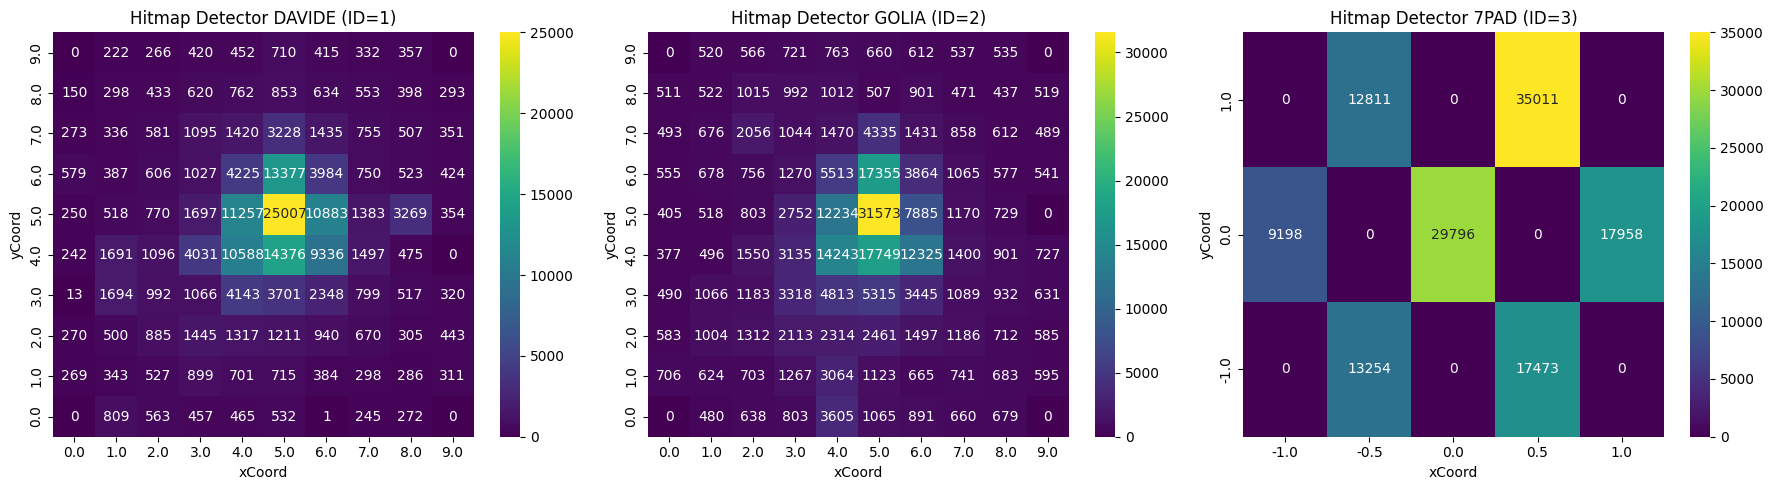

In [68]:
import seaborn as sns
import matplotlib.pyplot as plt 
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, det_id in enumerate([1, 2, 3]):
    df_all = df[df['Detector'] == det_id].copy()
    
    # Filtro extra per il Detector 2 (nota: nel tuo testo c'era scritto 3, ma l'if controllava det_id == 2)
    if det_id == 2:
        df_all = df_all[(df_all["xCoord"] != 9) | (df_all["yCoord"] != 5)]
    
    print(f"--- Primi 10 dati del Detector {det_id} ---")
    print(df_all.head(10))
    
    # TRUCCO: Trasformiamo i dati in una matrice (Griglia X-Y) 
    # Calcola quante volte ('count') appare la combinazione di xCoord e yCoord
    heatmap_data = df_all.pivot_table(
        index='yCoord', 
        columns='xCoord', 
        values='Detector',  # Una colonna qualsiasi per fare il conteggio
        aggfunc='count', 
        fill_value=0        # Mette 0 dove non ci sono hit (evita i valori NaN)
    )
    
    # Ora passiamo la matrice a sns.heatmap
    sns.heatmap(
        data=heatmap_data,
        ax=axes[i], 
        annot=True,        # Mostra i numeri
        fmt='d',           # 'd' mostra numeri interi (visto che sono conteggi)
        cmap='viridis'     # Un bell'effetto per le mappe di calore
    )
    
    # Invertiamo l'asse Y se vuoi che l'origine (0,0) sia in basso a sinistra
    axes[i].invert_yaxis() 
    # Impostiamo i titoli e le etichette 1==DAVIDE, 2==GOLIA, 3==7PAD
    #crea diziponario per i titoli
    titoli = {1: 'DAVIDE', 2: 'GOLIA', 3: '7PAD'}
    axes[i].set_xlabel('xCoord')
    axes[i].set_ylabel('yCoord')
    axes[i].set_title(f'Hitmap Detector {titoli[det_id]} (ID={det_id})')

plt.tight_layout()
plt.show()

LAVORO SU DET 2 aka GOLIA

In [69]:
#opèerating directly on pandas DataFrame

#at least 1 hit on detector 1
det1 = (df['Mult_det1'] == 1) & (df['event_idx'] > 100000) # primi 50000 eventi det 1 ha trippato
noisy = (df['xCoord'] != 9) | (df['yCoord'] != 5)
print(f"Eventi con  1 hit su det1: {det1.sum()}")


df_det1 = df[det1]
df_det1 = df_det1[noisy]
print(f"DataFrame filtrato (det1==1): {df_det1.shape}")
print(df_det1.head(50))

#plot di multiplicity per det

Eventi con  1 hit su det1: 523470
DataFrame filtrato (det1==1): (163408, 20)
        event_idx  Detector  Feb  Channel  Cell0TimeStamp   TimeInstant  \
165737     100002       2.0    1       51    1.497343e+11  1.497343e+11   
165805     100055       2.0    1       48    1.497621e+11  1.497621e+11   
165824     100074       2.0    1       34    1.497679e+11  1.497679e+11   
165876     100117       2.0    1       45    1.497997e+11  1.497997e+11   
165915     100154       2.0    2        1    1.498274e+11  1.498274e+11   
165917     100156       2.0    1       48    1.498295e+11  1.498295e+11   
165932     100166       2.0    1       55    1.498355e+11  1.498355e+11   
166010     100173       2.0    1       47    1.498424e+11  1.498424e+11   
166025     100188       2.0    2       28    1.498443e+11  1.498443e+11   
166077     100234       2.0    1       47    1.498882e+11  1.498882e+11   
166087     100244       2.0    1       52    1.498995e+11  1.498995e+11   
166088     100245      

/tmp/ipykernel_11972/3866084699.py:10: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_det1 = df_det1[noisy]


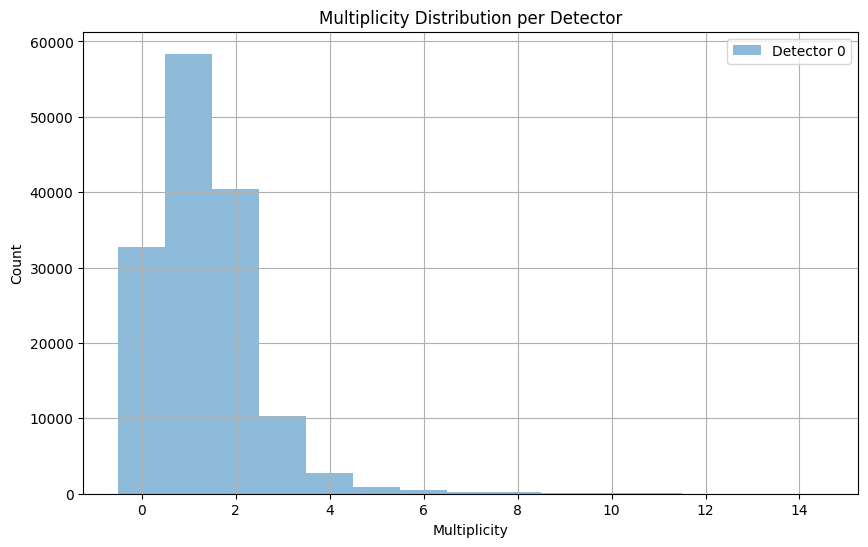

In [70]:
import matplotlib.pyplot as plt
#higher thshold for ampitude to exclude noise
df_det1 = df_det1[df_det1['Amplitude'] < -0.02] #escludiamo rumore con ampiezza < 0.02
plt.figure(figsize=(10, 6)) 
plt.hist(df_det1['Mult_det0'], bins=np.arange(-0.5, df_det1['Mult_det0'].max()+1.5, 1), alpha=0.5, label='Detector 0')
plt.xlabel('Multiplicity')
plt.ylabel('Count')
plt.title('Multiplicity Distribution per Detector')
plt.legend()
plt.grid()
plt.show()  

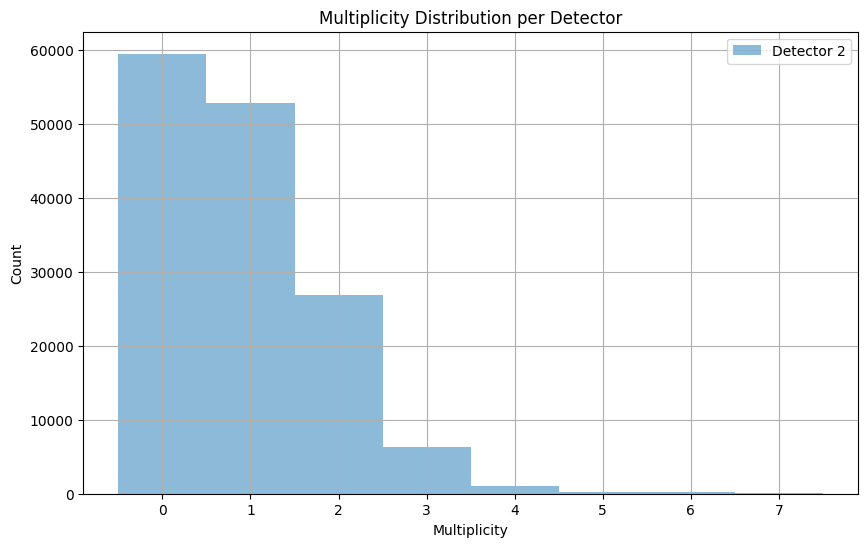

In [71]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6)) 

plt.hist(df_det1['Mult_det2'], bins=np.arange(-0.5, df_det1['Mult_det2'].max()+1.5, 1), alpha=0.5, label='Detector 2')
plt.xlabel('Multiplicity')
plt.ylabel('Count')
plt.title('Multiplicity Distribution per Detector')
plt.legend()
plt.grid()
plt.show()  

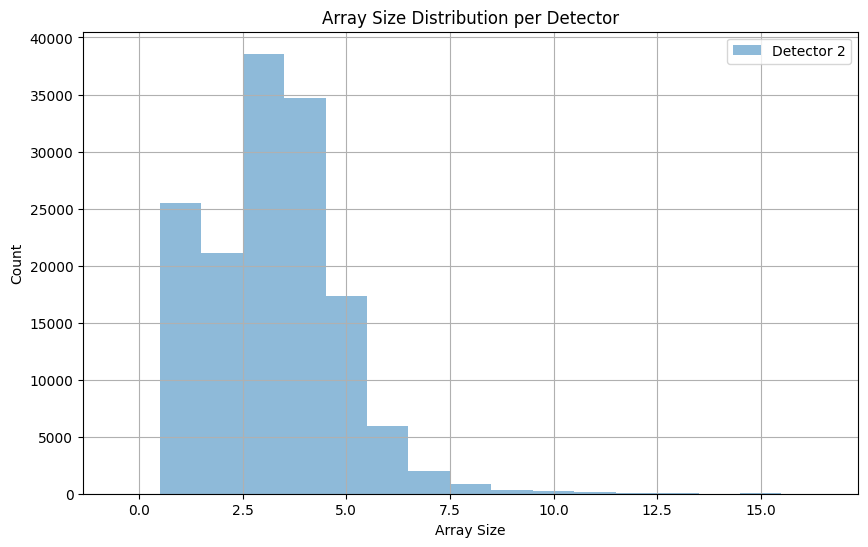

In [72]:
plt.figure(figsize=(10, 6)) 

plt.hist(df_det1['ArraySize'], bins=np.arange(-0.5, df_det1['ArraySize'].max()+1.5, 1), alpha=0.5, label='Detector 2')
plt.xlabel('Array Size')
plt.ylabel('Count')
plt.title('Array Size Distribution per Detector')
plt.legend()
plt.grid()
plt.show()  

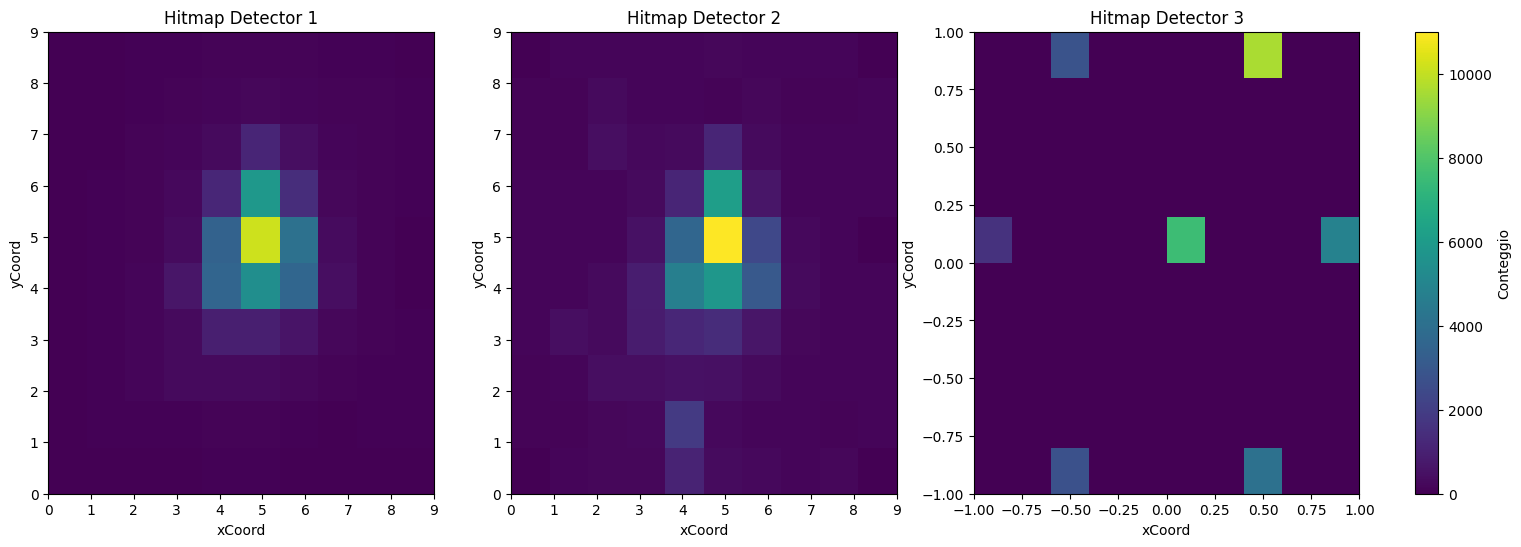

In [73]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

new_df = df_det1.copy()
new_df = df_det1[df_det1['ArraySize'] >= 1]

bins = 10
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# --- Primo passaggio: calcola tutti gli istogrammi e trova il max globale ---
histograms = []
for det_id in [1, 2, 3]:
    df_1 = new_df[new_df['Detector'] == det_id].copy()
    if det_id == 2:
        df_1 = df_1[(df_1["xCoord"] != 9) | (df_1["yCoord"] != 5)]
    
    h, xedges, yedges = np.histogram2d(df_1['xCoord'], df_1['yCoord'], bins=bins)
    histograms.append((h, xedges, yedges))

# Scala comune basata sul massimo reale dei dati
vmin = 0
vmax = max(h.max() for h, _, _ in histograms)
norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
cmap = 'viridis'

# --- Secondo passaggio: disegna con scala identica ---
for i, (det_id, (h, xedges, yedges)) in enumerate(zip([1, 2, 3], histograms)):
    ax = axes[i]
    mesh = ax.pcolormesh(xedges, yedges, h.T, cmap=cmap, norm=norm)
    ax.set_title(f'Hitmap Detector {det_id}')
    ax.set_xlabel('xCoord')
    ax.set_ylabel('yCoord')

# Colorbar unica condivisa
fig.colorbar(mesh, ax=axes, orientation='vertical', fraction=0.02, pad=0.04, label='Conteggio')

#plt.tight_layout()
plt.show()

--- Primi 10 dati del Detector 1 ---
       event_idx  Detector  Feb  Channel  Cell0TimeStamp   TimeInstant  \
479          359       1.0    1       30    2.018269e+09  2.018269e+09   
500          378       1.0    1       31    2.430461e+09  2.430461e+09   
501          378       1.0    1       30    2.430461e+09  2.430461e+09   
569          441       1.0    1       30    3.798623e+09  3.798623e+09   
570          441       1.0    1       31    3.798623e+09  3.798623e+09   
577          446       1.0    1       30    3.907405e+09  3.907405e+09   
578          446       1.0    1       31    3.907405e+09  3.907405e+09   
11110       5228       1.0    1       30    5.492481e+09  5.492481e+09   
11111       5228       1.0    1       14    5.492481e+09  5.492481e+09   
11158       5263       1.0    1       30    5.616407e+09  5.616407e+09   

       TOTValue  PeakValue  Baseline  Amplitude  xCoord  yCoord  ArraySize  \
479         0.0   0.729273  0.729273  -0.020698     1.0     0.0       

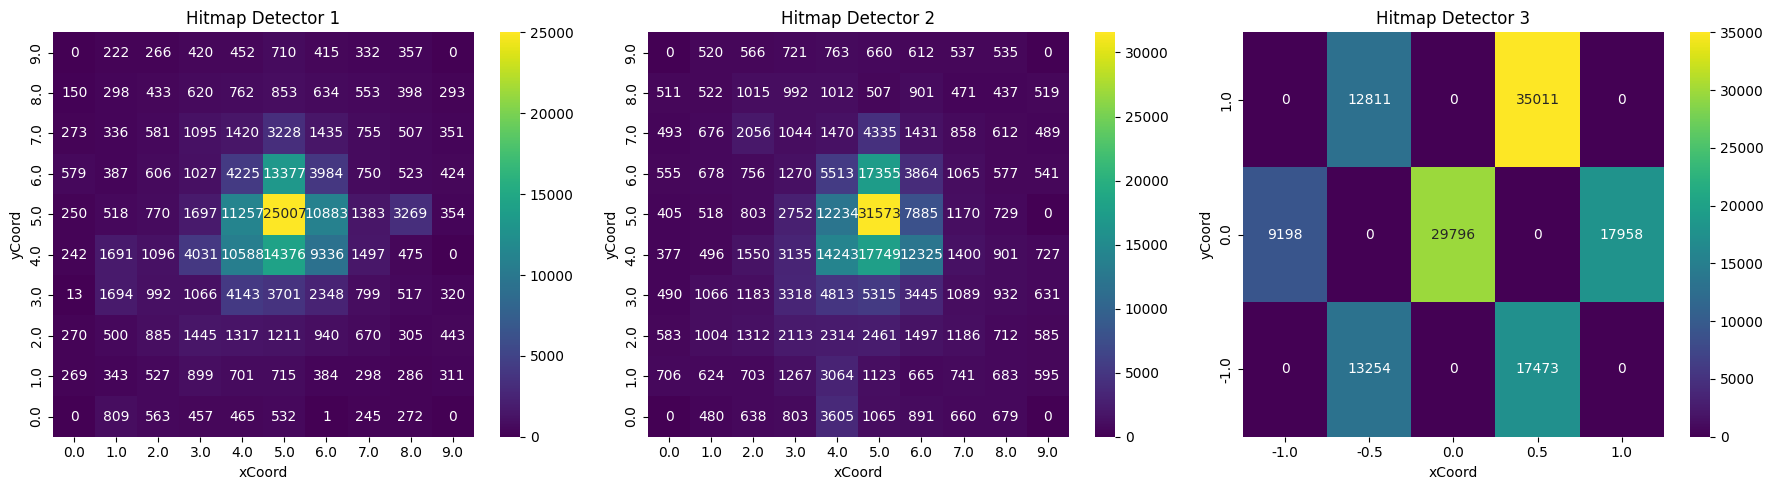

In [74]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Filtriamo i dati di partenza
#new_df = df_det1[df_det1['ArraySize'] >= 1]
different_df= df.copy()
# 2. Prepariamo la figura con i 3 spazi
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, det_id in enumerate([1, 2, 3]):
    df_1 = different_df[different_df['Detector'] == det_id].copy()
    
    # Filtro extra per il Detector 2 (nota: nel tuo testo c'era scritto 3, ma l'if controllava det_id == 2)
    if det_id == 2:
        df_1 = df_1[(df_1["xCoord"] != 9) | (df_1["yCoord"] != 5)]
    
    print(f"--- Primi 10 dati del Detector {det_id} ---")
    print(df_1.head(10))
    
    # TRUCCO: Trasformiamo i dati in una matrice (Griglia X-Y) 
    # Calcola quante volte ('count') appare la combinazione di xCoord e yCoord
    heatmap_data = df_1.pivot_table(
        index='yCoord', 
        columns='xCoord', 
        values='Detector',  # Una colonna qualsiasi per fare il conteggio
        aggfunc='count', 
        fill_value=0        # Mette 0 dove non ci sono hit (evita i valori NaN)
    )
    
    # Ora passiamo la matrice a sns.heatmap
    sns.heatmap(
        data=heatmap_data,
        ax=axes[i], 
        annot=True,        # Mostra i numeri
        fmt='d',           # 'd' mostra numeri interi (visto che sono conteggi)
        cmap='viridis'     # Un bell'effetto per le mappe di calore
    )
    
    # Invertiamo l'asse Y se vuoi che l'origine (0,0) sia in basso a sinistra
    axes[i].invert_yaxis() 
    axes[i].set_title(f'Hitmap Detector {det_id}')

plt.tight_layout()
plt.show()


In [75]:
# 1 hit su detector 2
#riempio tutto il resto >=1
# efficienza di davide facendo rapporto canale per canale 

#efficienza guardando i canali accoppiati: per ogni hit nel canale x guardo quante ce ne sono nel canale x dell'altro detector

#run 51 e run normale con intensità normale (run muoni)

Attenzione: efficienza > 1 per canale (3, 4) - hits_det1: 4031, hits_det2: 3135
Attenzione: efficienza > 1 per canale (6, 5) - hits_det1: 10883, hits_det2: 7885
Attenzione: efficienza > 1 per canale (6, 6) - hits_det1: 3984, hits_det2: 3864
Efficienza per Davide:
[[0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.28258755 0.         0.        ]
 [0.         0.         0.68386181 0.32127788 1.28580542 0.61664244
  0.         0.         0.         0.        ]
 [0.12898752 0.2287859  0.56914434 0.86079368 0.74338271 0.92014059
  0.7663704  0.         0.         0.        ]
 [0.         0.         0.49207639 0.69633114 0.80996112 0.7920375
  0.77078652 0.74463668 0.         0.        ]
 [0.         0.         0.         0.68156749 0.75748479 1.3802156
  1.

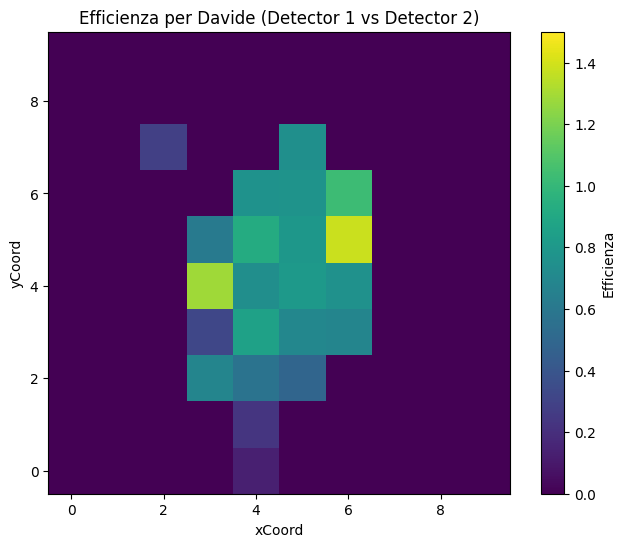

In [76]:
# efficienza davide = (hits con Detector 1) / (hits detector 2) canale per canale
#df_efficiency= new_df.copy()

df_1 = df.copy()
    
df_1 = df_1[(df_1["xCoord"] != 9) | (df_1["yCoord"] != 5)]
#df_1 = df_1[df_1["Mult_det0"] >= 1] 
    
efficiency = np.zeros((10, 10))  # matrice di efficienza per canale (x,y)
    
for x in range(10):
        for y in range(10):
            hits_det1 = len(df_1[(df_1['xCoord'] == x) & (df_1['yCoord'] == y) & (df_1['Detector'] == 1)])
            hits_det2 = len(df_1[(df_1['xCoord'] == x) & (df_1['yCoord'] == y) & (df_1['Detector'] == 2)])
            if hits_det2 < 2000:
                continue
            efficiency[x, y] = hits_det1 / hits_det2 if hits_det2 > 0 else 0
            
            if efficiency[x, y] > 1:
                print(f"Attenzione: efficienza > 1 per canale ({x}, {y}) - hits_det1: {hits_det1}, hits_det2: {hits_det2}")

print(f"Efficienza per Davide:\n{efficiency}")
plt.figure(figsize=(8, 6))
plt.imshow(efficiency.T, origin='lower', cmap='viridis', vmin=0, vmax=1.5)
plt.colorbar(label='Efficienza')
plt.title('Efficienza per Davide (Detector 1 vs Detector 2)')
plt.xlabel('xCoord')
plt.ylabel('yCoord')
#plt.grid()
plt.show()


--- Primi 10 dati del Detector 1 ---
        event_idx  Detector  Feb  Channel  Cell0TimeStamp   TimeInstant  \
177185     110707       1.0    3       30    1.601867e+11  1.601867e+11   
177285     110786       1.0    3       29    1.602680e+11  1.602680e+11   
177337     110822       1.0    3       42    1.602907e+11  1.602907e+11   
177342     110825       1.0    3        7    1.602922e+11  1.602922e+11   
177360     110837       1.0    3       41    1.602970e+11  1.602970e+11   
177371     110847       1.0    3       48    1.602975e+11  1.602975e+11   
177380     110854       1.0    3       29    1.603021e+11  1.603021e+11   
177381     110854       1.0    3       22    1.603021e+11  1.603021e+11   
177385     110856       1.0    3       49    1.603031e+11  1.603031e+11   
177393     110859       1.0    3       41    1.603056e+11  1.603056e+11   

        TOTValue  PeakValue  Baseline  Amplitude  xCoord  yCoord  ArraySize  \
177185       0.0   0.736936  0.736936  -0.042268     8.0  

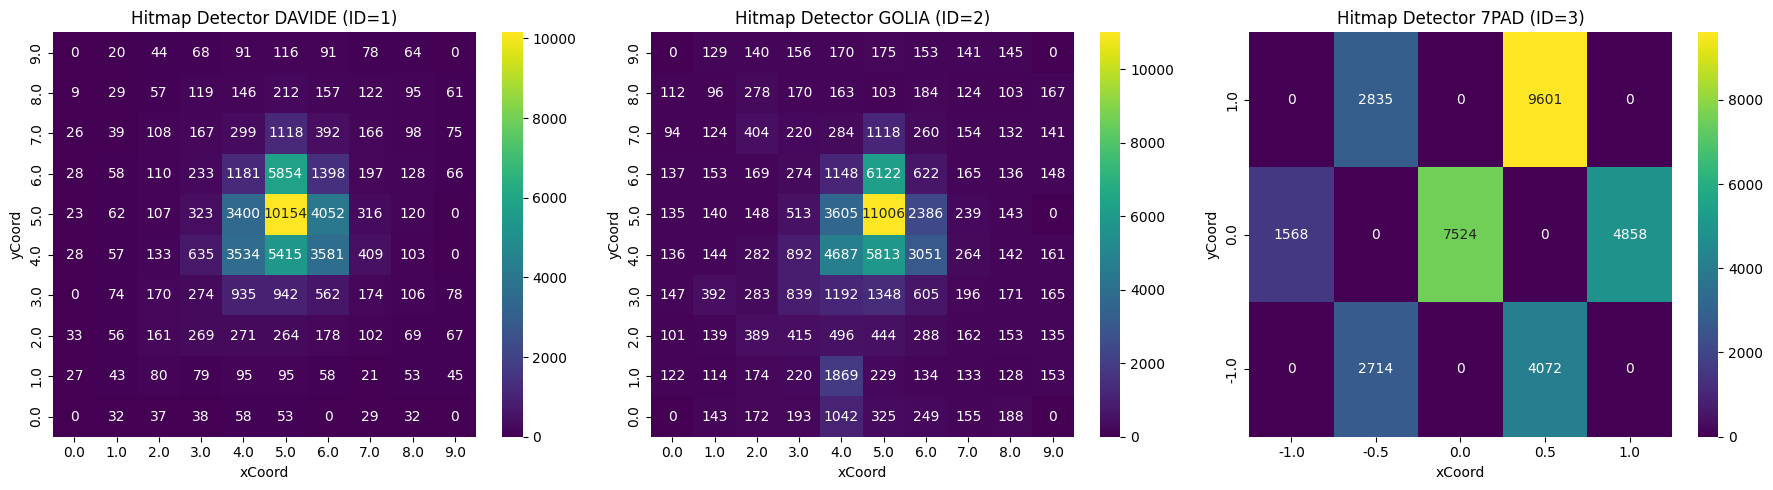

In [77]:
# 1. Filtriamo i dati di partenza (INUTILE PERCHE CHIEO ALMENO 1 HIT)
#new_df = df_det1.copy()
#new_df = df_det1[df_det1['ArraySize'] >= 1]
new_df = new_df[new_df['Mult_det0'] >= 0]
#new_df = new_df[new_df['Mult_det2'] == 1]

# 2. Prepariamo la figura con i 3 spazi
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, det_id in enumerate([1, 2, 3]):
    df_1 = new_df[new_df['Detector'] == det_id].copy()
    
    # Filtro extra per il Detector 2 (nota: nel tuo testo c'era scritto 3, ma l'if controllava det_id == 2)
    if det_id == 2:
        df_1 = df_1[(df_1["xCoord"] != 9) | (df_1["yCoord"] != 5)]
    
    print(f"--- Primi 10 dati del Detector {det_id} ---")
    print(df_1.head(10))
    
    # TRUCCO: Trasformiamo i dati in una matrice (Griglia X-Y) 
    # Calcola quante volte ('count') appare la combinazione di xCoord e yCoord
    heatmap_data = df_1.pivot_table(
        index='yCoord', 
        columns='xCoord', 
        values='Detector',  # Una colonna qualsiasi per fare il conteggio
        aggfunc='count', 
        fill_value=0        # Mette 0 dove non ci sono hit (evita i valori NaN)
    )
    
    # Ora passiamo la matrice a sns.heatmap
    sns.heatmap(
        data=heatmap_data,
        ax=axes[i], 
        annot=True,        # Mostra i numeri
        fmt='d',           # 'd' mostra numeri interi (visto che sono conteggi)
        cmap='viridis'     # Un bell'effetto per le mappe di calore
    )
    
    # Invertiamo l'asse Y se vuoi che l'origine (0,0) sia in basso a sinistra
    #dizionario per i titoli
    titoli = {1: 'DAVIDE', 2: 'GOLIA', 3: '7PAD'}
    axes[i].invert_yaxis() 
    axes[i].set_title(f'Hitmap Detector {titoli[det_id]} (ID={det_id})')

plt.tight_layout()
plt.show()

Attenzione: efficienza > 1 per canale (4, 6) - hits_det1: 1181, hits_det2: 1148
Attenzione: efficienza > 1 per canale (6, 4) - hits_det1: 3581, hits_det2: 3051
Attenzione: efficienza > 1 per canale (6, 5) - hits_det1: 4052, hits_det2: 2386
Attenzione: efficienza > 1 per canale (6, 6) - hits_det1: 1398, hits_det2: 622
Efficienza per Davide:
[[0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.32657926 0.71188341 0.62962963
  0.         0.         0.         0.        ]
 [0.05566219 0.05082932 0.         0.78439597 0.75400043 0.94313454
  1.02874564 0.         0.         0.        ]
 [0.         0.         0.         0.69881306 0.93153277 0.92258768
  0.95622346 1.         0.         0.  

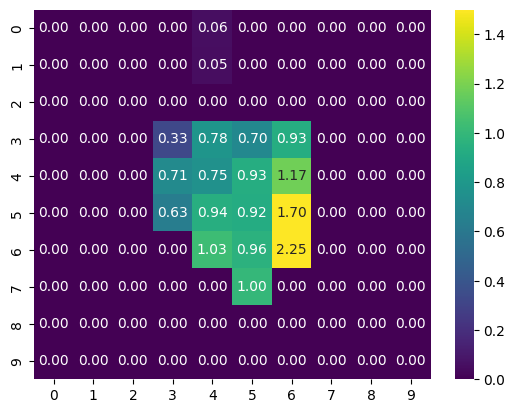

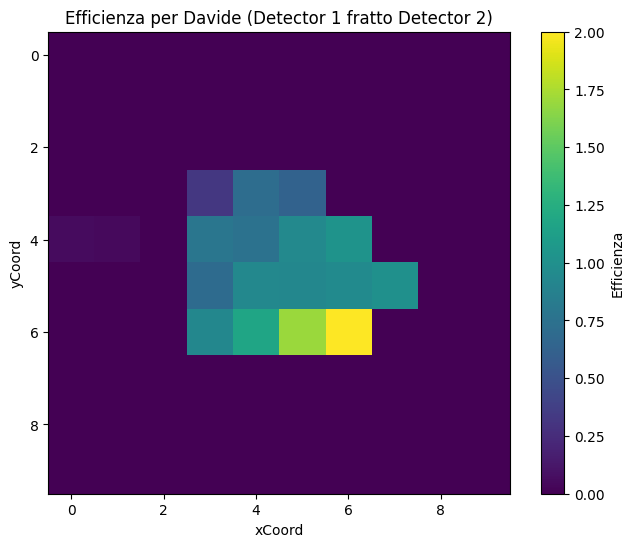

In [78]:
df_2=new_df.copy()
df_2 = df_2[df_2["Mult_det0"] >= 0]
#df_2 = df_2[df_2["Mult_det2"] == 1]

df_2 = df_2[(df_2["xCoord"] != 9) | (df_2["yCoord"] != 5)]

efficiency = np.zeros((10, 10))  # matrice di efficienza per canale (x,y)


for x in range(10):
        for y in range(10):
            hits_det1 = len(df_2[(df_2['xCoord'] == x) & (df_2['yCoord'] == y) & (df_2['Detector'] == 1)])
            hits_det2 = len(df_2[(df_2['xCoord'] == x) & (df_2['yCoord'] == y) & (df_2['Detector'] == 2)])
            if(hits_det2< 500):
                 continue
            efficiency[x, y] = hits_det1 / hits_det2 if hits_det2 > 0 else 0
            if efficiency[x, y] > 1:
                print(f"Attenzione: efficienza > 1 per canale ({x}, {y}) - hits_det1: {hits_det1}, hits_det2: {hits_det2}")

print(f"Efficienza per Davide:\n{efficiency}")
sns.heatmap(efficiency.T, annot=True, fmt=".2f", cmap='viridis', vmin=0, vmax=1.5)
plt.figure(figsize=(8, 6))
plt.imshow(efficiency, cmap='viridis', vmin=0, vmax=2)
plt.colorbar(label='Efficienza')
plt.title('Efficienza per Davide (Detector 1 fratto Detector 2)')
plt.xlabel('xCoord')
plt.ylabel('yCoord')
#plt.grid()
plt.show()

--- Primi 10 dati del Detector 1 ---
        event_idx  Detector  Feb  Channel  Cell0TimeStamp   TimeInstant  \
177185     110707       1.0    3       30    1.601867e+11  1.601867e+11   
177337     110822       1.0    3       42    1.602907e+11  1.602907e+11   
177342     110825       1.0    3        7    1.602922e+11  1.602922e+11   
177360     110837       1.0    3       41    1.602970e+11  1.602970e+11   
177371     110847       1.0    3       48    1.602975e+11  1.602975e+11   
177385     110856       1.0    3       49    1.603031e+11  1.603031e+11   
177408     110869       1.0    3       41    1.603111e+11  1.603111e+11   
177430     110881       1.0    3        9    1.603180e+11  1.603180e+11   
177432     110882       1.0    3       18    1.603188e+11  1.603188e+11   
177442     110888       1.0    3        3    1.603246e+11  1.603246e+11   

        TOTValue  PeakValue  Baseline  Amplitude  xCoord  yCoord  ArraySize  \
177185       0.0   0.736936  0.736936  -0.042268     8.0  

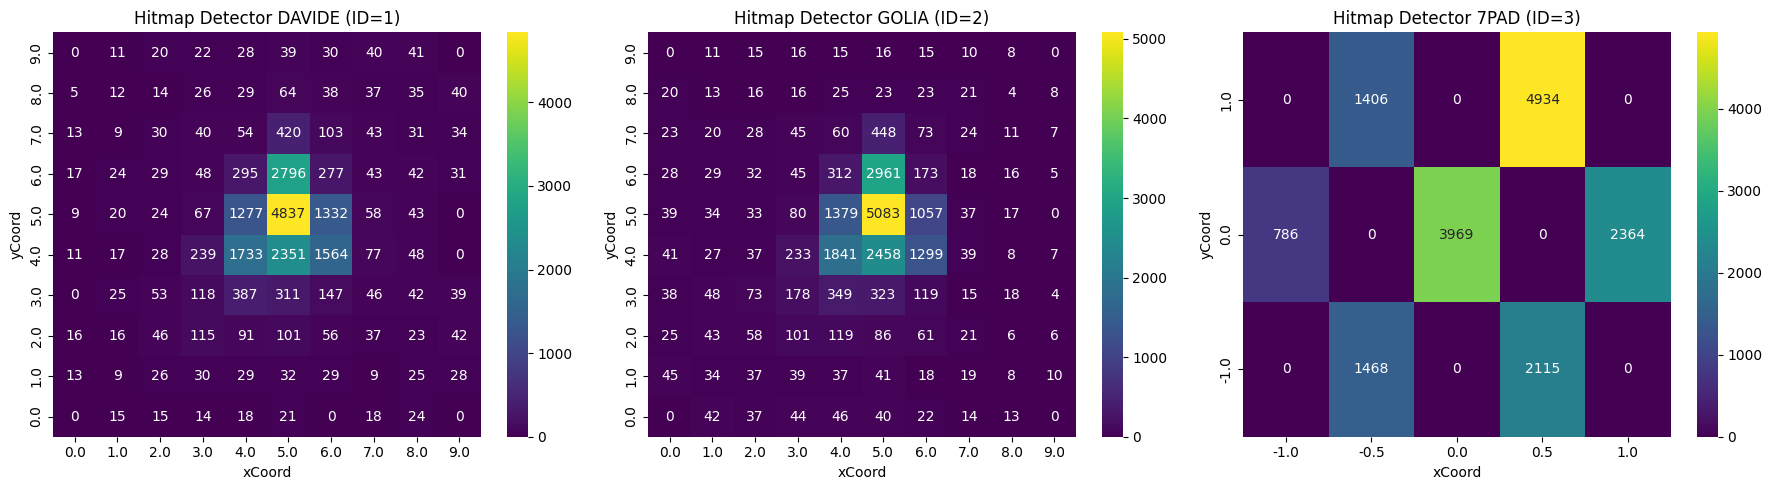

In [79]:
# 1. Filtriamo i dati di partenza (INUTILE PERCHE CHIEO ALMENO 1 HIT)
new_df = df_det1[df_det1['ArraySize'] >= 1]
new_df = new_df[new_df['Mult_det0'] == 1]
#new_df = new_df[new_df['Mult_det2'] == 1]

# 2. Prepariamo la figura con i 3 spazi
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, det_id in enumerate([1, 2, 3]):
    df_1 = new_df[new_df['Detector'] == det_id].copy()
    
    # Filtro extra per il Detector 2 (nota: nel tuo testo c'era scritto 3, ma l'if controllava det_id == 2)
    if det_id == 2:
        df_1 = df_1[(df_1["xCoord"] != 9) | (df_1["yCoord"] != 5)]
    
    print(f"--- Primi 10 dati del Detector {det_id} ---")
    print(df_1.head(10))
    
    # TRUCCO: Trasformiamo i dati in una matrice (Griglia X-Y) 
    # Calcola quante volte ('count') appare la combinazione di xCoord e yCoord
    heatmap_data = df_1.pivot_table(
        index='yCoord', 
        columns='xCoord', 
        values='Detector',  # Una colonna qualsiasi per fare il conteggio
        aggfunc='count', 
        fill_value=0        # Mette 0 dove non ci sono hit (evita i valori NaN)
    )
    
    # Ora passiamo la matrice a sns.heatmap
    sns.heatmap(
        data=heatmap_data,
        ax=axes[i], 
        annot=True,        # Mostra i numeri
        fmt='d',           # 'd' mostra numeri interi (visto che sono conteggi)
        cmap='viridis'     # Un bell'effetto per le mappe di calore
    )
    
    # Invertiamo l'asse Y se vuoi che l'origine (0,0) sia in basso a sinistra
    #dizionario per i titoli
    titoli = {1: 'DAVIDE', 2: 'GOLIA', 3: '7PAD'}
    axes[i].invert_yaxis() 
    axes[i].set_title(f'Hitmap Detector {titoli[det_id]} (ID={det_id})')

plt.tight_layout()
plt.show()

Attenzione: efficienza > 1 per canale (3, 2) - hits_det1: 115, hits_det2: 101
Attenzione: efficienza > 1 per canale (3, 4) - hits_det1: 239, hits_det2: 233
Attenzione: efficienza > 1 per canale (4, 3) - hits_det1: 387, hits_det2: 349
Attenzione: efficienza > 1 per canale (6, 3) - hits_det1: 147, hits_det2: 119
Attenzione: efficienza > 1 per canale (6, 4) - hits_det1: 1564, hits_det2: 1299
Attenzione: efficienza > 1 per canale (6, 5) - hits_det1: 1332, hits_det2: 1057
Attenzione: efficienza > 1 per canale (6, 6) - hits_det1: 277, hits_det2: 173
Efficienza per Davide:
[[0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         1.13861386 0.66292135 1.02575107 0.
  0.         0.         0.         0.        ]

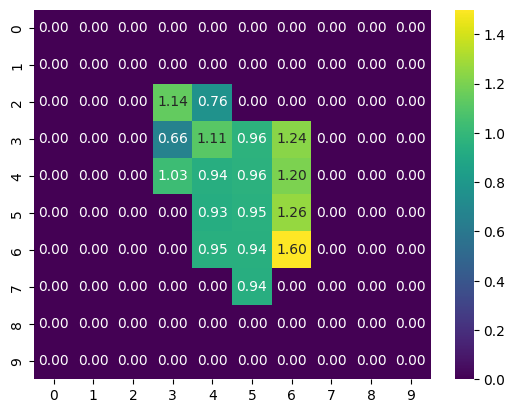

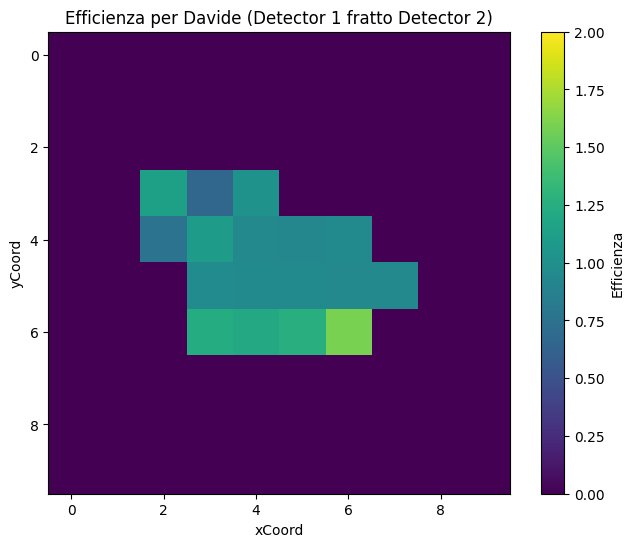

In [80]:
df_2=new_df.copy()
df_2 = df_2[df_2["Mult_det0"] >= 0]
#df_2 = df_2[df_2["Mult_det2"] == 1]

df_2 = df_2[(df_2["xCoord"] != 9) | (df_2["yCoord"] != 5)]

efficiency = np.zeros((10, 10))  # matrice di efficienza per canale (x,y)


for x in range(10):
        for y in range(10):
            hits_det1 = len(df_2[(df_2['xCoord'] == x) & (df_2['yCoord'] == y) & (df_2['Detector'] == 1)])
            hits_det2 = len(df_2[(df_2['xCoord'] == x) & (df_2['yCoord'] == y) & (df_2['Detector'] == 2)])
            if(hits_det2< 100):
                 continue
            efficiency[x, y] = hits_det1 / hits_det2 if hits_det2 > 0 else 0
            if efficiency[x, y] > 1:
                print(f"Attenzione: efficienza > 1 per canale ({x}, {y}) - hits_det1: {hits_det1}, hits_det2: {hits_det2}")

print(f"Efficienza per Davide:\n{efficiency}")
sns.heatmap(efficiency.T, annot=True, fmt=".2f", cmap='viridis', vmin=0, vmax=1.5)
plt.figure(figsize=(8, 6))
plt.imshow(efficiency, cmap='viridis', vmin=0, vmax=2)
plt.colorbar(label='Efficienza')
plt.title('Efficienza per Davide (Detector 1 fratto Detector 2)')
plt.xlabel('xCoord')
plt.ylabel('yCoord')
#plt.grid()
plt.show()

LAVORO SU DET 1 aka DAVIDE

In [81]:
df_Davide = df.copy()
conditions = (df_Davide['Mult_det0'] == 1) & ((df_Davide["xCoord"] != 9) | (df_Davide["yCoord"] != 5))
df_Davide = df_Davide[conditions]
print(df_Davide.head(50))

       event_idx  Detector  Feb  Channel  Cell0TimeStamp   TimeInstant  \
479          359       1.0    1       30    2.018269e+09  2.018269e+09   
11158       5263       1.0    1       30    5.616407e+09  5.616407e+09   
11315       5362       1.0    1       31    5.761773e+09  5.761773e+09   
11671       5530       1.0    1       31    6.319070e+09  6.319070e+09   
12033       5783       1.0    1       14    7.813595e+09  7.813595e+09   
12080       5821       1.0    1       30    8.155114e+09  8.155114e+09   
12194       5922       1.0    1       30    9.271011e+09  9.271011e+09   
12208       5935       1.0    1       31    9.344570e+09  9.344570e+09   
12409       6097       1.0    1       31    1.099859e+10  1.099859e+10   
12410       6098       1.0    1       30    1.099988e+10  1.099988e+10   
13057       6603       1.0    1       30    1.451030e+10  1.451030e+10   
13186       6713       1.0    1       30    1.623679e+10  1.623679e+10   
13229       6750       1.0    1       

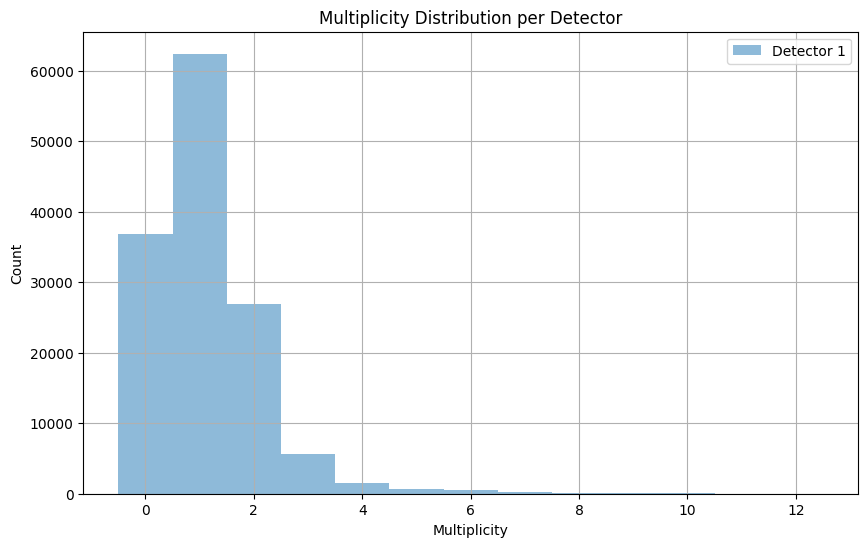

In [82]:
import matplotlib.pyplot as plt
#higher thshold for ampitude to exclude noise
df_Davide = df_Davide[df_Davide['Amplitude'] < -0.02] #escludiamo rumore con ampiezza < 0.02
plt.figure(figsize=(10, 6)) 
plt.hist(df_Davide['Mult_det1'], bins=np.arange(-0.5, df_Davide['Mult_det1'].max()+1.5, 1), alpha=0.5, label='Detector 1')
plt.xlabel('Multiplicity')
plt.ylabel('Count')
plt.title('Multiplicity Distribution per Detector')
plt.legend()
plt.grid()
plt.show()  

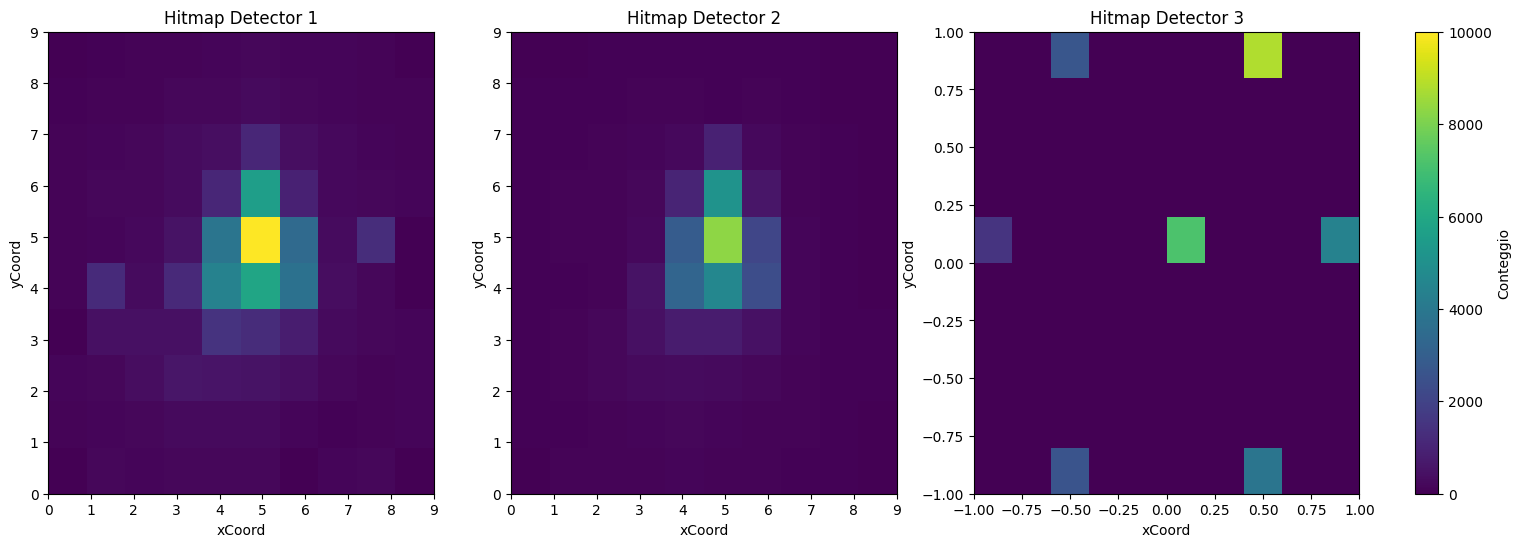

In [83]:


new_df = df_Davide[df_Davide['ArraySize'] >= 1]

bins = 10
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# --- Primo passaggio: calcola tutti gli istogrammi e trova il max globale ---
histograms = []
for det_id in [1, 2, 3]:
    df_1 = new_df[new_df['Detector'] == det_id].copy()
    if det_id == 2:
        df_1 = df_1[(df_1["xCoord"] != 9) | (df_1["yCoord"] != 5)]
    
    h, xedges, yedges = np.histogram2d(df_1['xCoord'], df_1['yCoord'], bins=bins)
    histograms.append((h, xedges, yedges))

# Scala comune basata sul massimo reale dei dati
vmin = 0
vmax = max(h.max() for h, _, _ in histograms)
norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
cmap = 'viridis'

# --- Secondo passaggio: disegna con scala identica ---
for i, (det_id, (h, xedges, yedges)) in enumerate(zip([1, 2, 3], histograms)):
    ax = axes[i]
    mesh = ax.pcolormesh(xedges, yedges, h.T, cmap=cmap, norm=norm)
    ax.set_title(f'Hitmap Detector {det_id}')
    ax.set_xlabel('xCoord')
    ax.set_ylabel('yCoord')

# Colorbar unica condivisa
fig.colorbar(mesh, ax=axes, orientation='vertical', fraction=0.02, pad=0.04, label='Conteggio')

#plt.tight_layout()
plt.show()

--- Primi 10 dati del Detector 1 ---
        event_idx  Detector  Feb  Channel  Cell0TimeStamp   TimeInstant  \
479           359       1.0    1       30    2.018269e+09  2.018269e+09   
36249       17907       1.0    1       30    3.636209e+10  3.636209e+10   
36938       18469       1.0    1       30    4.232121e+10  4.232121e+10   
37615       18975       1.0    1       30    4.644188e+10  4.644188e+10   
48574       23849       1.0    1       30    4.914208e+10  4.914208e+10   
51454       26096       1.0    1       30    7.558535e+10  7.558535e+10   
53641       27055       1.0    1       30    7.616032e+10  7.616032e+10   
74546       37058       1.0    1       30    9.358528e+10  9.358528e+10   
88204       44918       1.0    1       30    1.072842e+11  1.072842e+11   
101174      57456       1.0    1       30    1.193432e+11  1.193432e+11   

        TOTValue  PeakValue  Baseline  Amplitude  xCoord  yCoord  ArraySize  \
479          0.0   0.729273  0.729273  -0.020698     1.0  

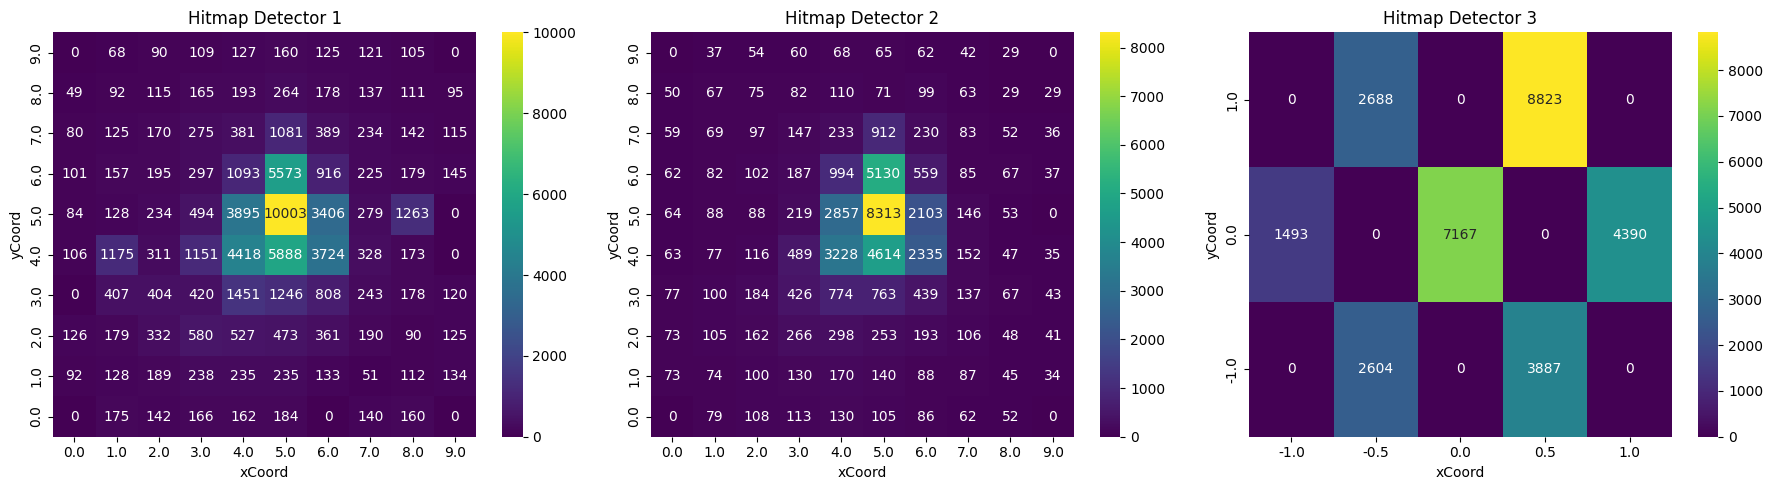

In [84]:
# 1. Filtriamo i dati di partenza
new_df = df_Davide[df_Davide['ArraySize'] >= 1]

# 2. Prepariamo la figura con i 3 spazi
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, det_id in enumerate([1, 2, 3]):
    df_1 = new_df[new_df['Detector'] == det_id].copy()
    
    # Filtro extra per il Detector 2 (nota: nel tuo testo c'era scritto 3, ma l'if controllava det_id == 2)
    if det_id == 2:
        df_1 = df_1[(df_1["xCoord"] != 9) | (df_1["yCoord"] != 5)]
    
    print(f"--- Primi 10 dati del Detector {det_id} ---")
    print(df_1.head(10))
    
    # TRUCCO: Trasformiamo i dati in una matrice (Griglia X-Y) 
    # Calcola quante volte ('count') appare la combinazione di xCoord e yCoord
    heatmap_data = df_1.pivot_table(
        index='yCoord', 
        columns='xCoord', 
        values='Detector',  # Una colonna qualsiasi per fare il conteggio
        aggfunc='count', 
        fill_value=0        # Mette 0 dove non ci sono hit (evita i valori NaN)
    )
    
    # Ora passiamo la matrice a sns.heatmap
    sns.heatmap(
        data=heatmap_data,
        ax=axes[i], 
        annot=True,        # Mostra i numeri
        fmt='d',           # 'd' mostra numeri interi (visto che sono conteggi)
        cmap='viridis'     # Un bell'effetto per le mappe di calore
    )
    
    # Invertiamo l'asse Y se vuoi che l'origine (0,0) sia in basso a sinistra
    axes[i].invert_yaxis() 
    axes[i].set_title(f'Hitmap Detector {det_id}')

plt.tight_layout()
plt.show()


In [85]:
#corrispondenza canale per canale tra det1 e det2: per ogni hit in det1 guardo se c'è un hit nello stesso canale in det2
#nel caso di charge sharing riempio solo la cella corrispodente al detector 2 aka golia

Efficienza per Golia:
[[0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.73064735 0.73350449
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.78362772 0.83105068
  0.9205096  0.         0.         0.        ]
 [0.         0.         0.         0.         0.62701396 0.61743981
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0. 

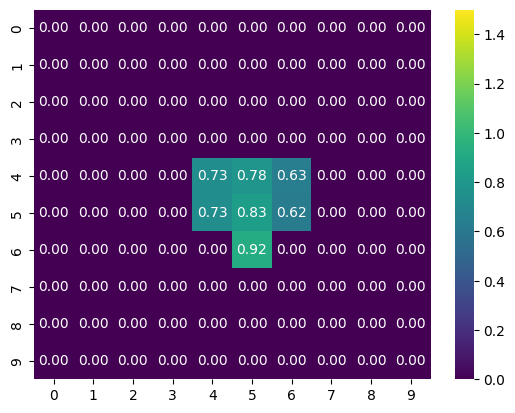

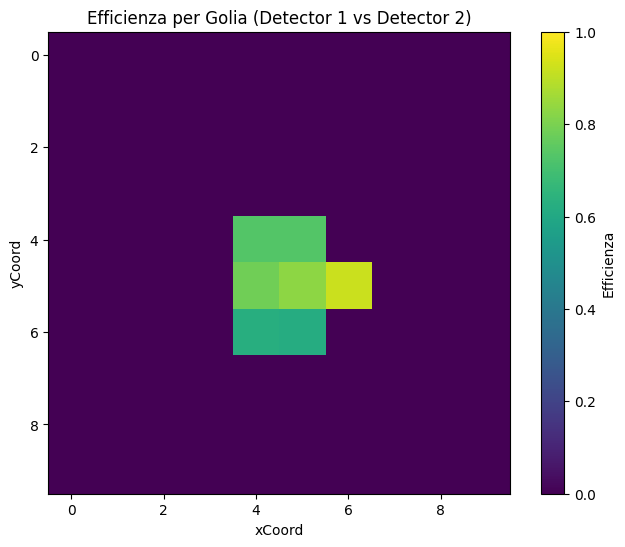

In [86]:
df_1 = new_df.copy()
    
df_1 = df_1[(df_1["xCoord"] != 9) | (df_1["yCoord"] != 5)]
df_1 = df_1[df_1["Mult_det1"] >= 0] 
    
efficiency = np.zeros((10, 10))  # matrice di efficienza per canale (x,y)
    
for x in range(10):
        for y in range(10):
            hits_det1 = len(df_1[(df_1['xCoord'] == x) & (df_1['yCoord'] == y) & (df_1['Detector'] == 1)])
            hits_det2 = len(df_1[(df_1['xCoord'] == x) & (df_1['yCoord'] == y) & (df_1['Detector'] == 2)])
            if hits_det2 < 1000:
                continue
            efficiency[x, y] = hits_det2 / hits_det1 if hits_det1 > 0 else 0
            
            if efficiency[x, y] > 1:
                print(f"Attenzione: efficienza > 1 per canale ({x}, {y}) - hits_det1: {hits_det1}, hits_det2: {hits_det2}")

print(f"Efficienza per Golia:\n{efficiency}")
sns.heatmap(efficiency.T, annot=True, fmt=".2f", cmap='viridis', vmin=0, vmax=1.5)
plt.figure(figsize=(8, 6))
plt.imshow(efficiency,  cmap='viridis', vmin=0, vmax=1)
plt.colorbar(label='Efficienza')
plt.title('Efficienza per Golia (Detector 1 vs Detector 2)')
plt.xlabel('xCoord')
plt.ylabel('yCoord')
#plt.grid()
plt.show()

TRIGGERING ON DET 3

In [87]:
df_7pad = df.copy()
df_7pad = df_7pad[df_7pad['Mult_det2'] == 1]
print(df_7pad.head(50))

     event_idx  Detector  Feb  Channel  Cell0TimeStamp   TimeInstant  \
2            2       3.0    0        3    1.095596e+08  1.095597e+08   
3            3       3.0    0        7    1.238100e+08  1.238100e+08   
4            4       3.0    0        6    1.336108e+08  1.336108e+08   
5            5       3.0    0        6    1.357037e+08  1.357037e+08   
6            6       3.0    0        1    2.081963e+08  2.081963e+08   
16          13       3.0    0        2    3.217190e+08  3.217190e+08   
18          15       3.0    0        7    3.466221e+08  3.466221e+08   
19          16       3.0    0        2    3.604384e+08  3.604384e+08   
20          17       3.0    0        2    4.026171e+08  4.026171e+08   
25          22       3.0    0        4    4.928269e+08  4.928269e+08   
26          23       3.0    0        4    4.976090e+08  4.976090e+08   
29          26       3.0    0        5    5.449376e+08  5.449376e+08   
30          27       3.0    0        3    5.567787e+08  5.567787

--- Primi 10 dati del Detector 1 ---
        event_idx  Detector  Feb  Channel  Cell0TimeStamp   TimeInstant  \
123003      73063       1.0    3       23    1.303167e+11  1.303167e+11   
123004      73063       1.0    3       16    1.303167e+11  1.303167e+11   
123694      73560       1.0    3       17    1.305500e+11  1.305500e+11   
126963      76734       1.0    1        3    1.337530e+11  1.337530e+11   
126964      76734       1.0    3       45    1.337530e+11  1.337530e+11   
126965      76734       1.0    3       29    1.337530e+11  1.337530e+11   
126968      76735       1.0    3       51    1.337530e+11  1.337530e+11   
126976      76737       1.0    1       11    1.337531e+11  1.337531e+11   
126977      76737       1.0    3       52    1.337531e+11  1.337531e+11   
126978      76737       1.0    3       48    1.337531e+11  1.337531e+11   

        TOTValue  PeakValue  Baseline  Amplitude  xCoord  yCoord  ArraySize  \
123003       0.0   0.737888  0.737888  -0.051462     9.0  

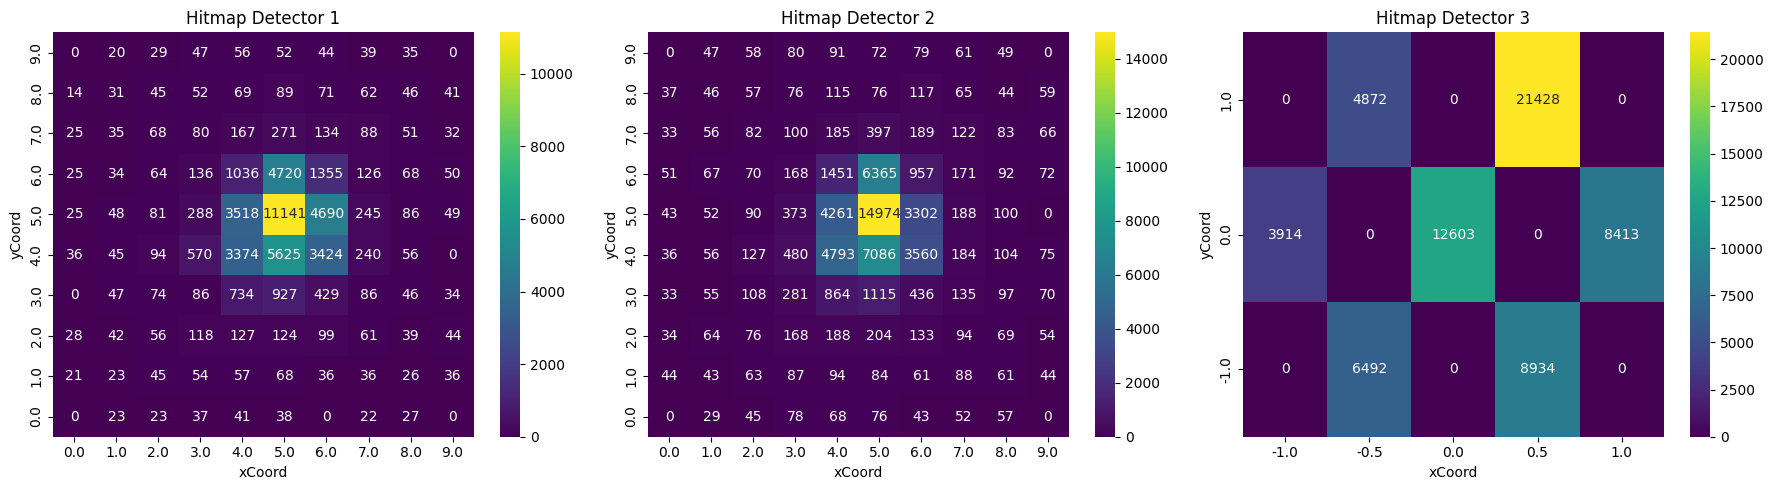

In [88]:
# 1. Filtriamo i dati di partenza
new_df = df_7pad[df_7pad['ArraySize'] >= 1]

# 2. Prepariamo la figura con i 3 spazi
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, det_id in enumerate([1, 2, 3]):
    df_1 = new_df[new_df['Detector'] == det_id].copy()
    
    # Filtro extra per il Detector 2 (nota: nel tuo testo c'era scritto 3, ma l'if controllava det_id == 2)
    if det_id == 2:
        df_1 = df_1[(df_1["xCoord"] != 9) | (df_1["yCoord"] != 5)]
    
    print(f"--- Primi 10 dati del Detector {det_id} ---")
    print(df_1.head(10))
    
    # TRUCCO: Trasformiamo i dati in una matrice (Griglia X-Y) 
    # Calcola quante volte ('count') appare la combinazione di xCoord e yCoord
    heatmap_data = df_1.pivot_table(
        index='yCoord', 
        columns='xCoord', 
        values='Detector',  # Una colonna qualsiasi per fare il conteggio
        aggfunc='count', 
        fill_value=0        # Mette 0 dove non ci sono hit (evita i valori NaN)
    )
    
    # Ora passiamo la matrice a sns.heatmap
    sns.heatmap(
        data=heatmap_data,
        ax=axes[i], 
        annot=True,        # Mostra i numeri
        fmt='d',           # 'd' mostra numeri interi (visto che sono conteggi)
        cmap='viridis'     # Un bell'effetto per le mappe di calore
    )
    
    # Invertiamo l'asse Y se vuoi che l'origine (0,0) sia in basso a sinistra
    axes[i].invert_yaxis() 
    axes[i].set_title(f'Hitmap Detector {det_id}')

plt.tight_layout()
plt.show()

Attenzione: efficienza > 1 per canale (4, 4) - hits_det1: 3374, hits_det2: 4793
Attenzione: efficienza > 1 per canale (4, 5) - hits_det1: 3518, hits_det2: 4261
Attenzione: efficienza > 1 per canale (4, 6) - hits_det1: 1036, hits_det2: 1451
Attenzione: efficienza > 1 per canale (5, 3) - hits_det1: 927, hits_det2: 1115
Attenzione: efficienza > 1 per canale (5, 4) - hits_det1: 5625, hits_det2: 7086
Attenzione: efficienza > 1 per canale (5, 5) - hits_det1: 11141, hits_det2: 14974
Attenzione: efficienza > 1 per canale (5, 6) - hits_det1: 4720, hits_det2: 6365
Attenzione: efficienza > 1 per canale (6, 4) - hits_det1: 3424, hits_det2: 3560
Efficienza per Golia:
[[0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0. 

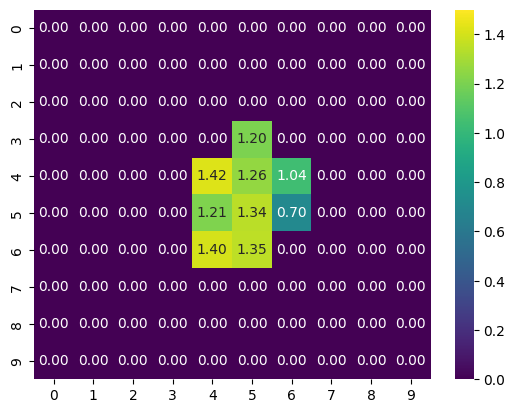

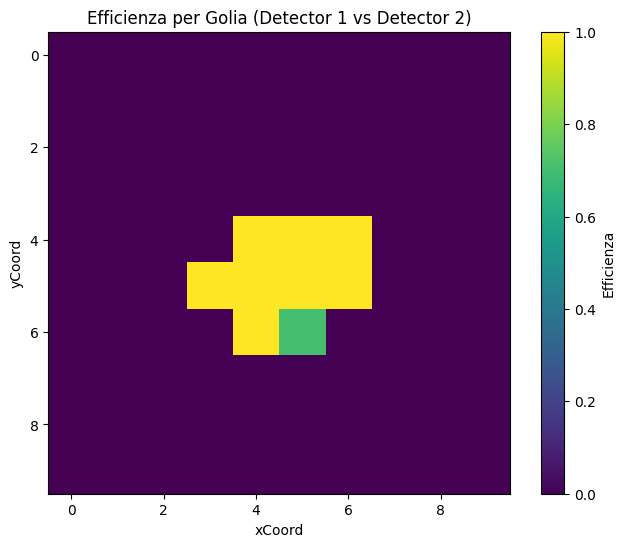

In [89]:
df_1 = new_df.copy()
    
df_1 = df_1[(df_1["xCoord"] != 9) | (df_1["yCoord"] != 5)]
df_1 = df_1[df_1["Mult_det1"] >= 0] 
    
efficiency = np.zeros((10, 10))  # matrice di efficienza per canale (x,y)
    
for x in range(10):
        for y in range(10):
            hits_det1 = len(df_1[(df_1['xCoord'] == x) & (df_1['yCoord'] == y) & (df_1['Detector'] == 1)])
            hits_det2 = len(df_1[(df_1['xCoord'] == x) & (df_1['yCoord'] == y) & (df_1['Detector'] == 2)])
            if hits_det2 < 1000:
                continue
            efficiency[x, y] = hits_det2 / hits_det1 if hits_det1 > 0 else 0
            
            if efficiency[x, y] > 1:
                print(f"Attenzione: efficienza > 1 per canale ({x}, {y}) - hits_det1: {hits_det1}, hits_det2: {hits_det2}")

print(f"Efficienza per Golia:\n{efficiency}")
sns.heatmap(efficiency.T, annot=True, fmt=".2f", cmap='viridis', vmin=0, vmax=1.5)
plt.figure(figsize=(8, 6))
plt.imshow(efficiency,  cmap='viridis', vmin=0, vmax=1)
plt.colorbar(label='Efficienza')
plt.title('Efficienza per Golia (Detector 1 vs Detector 2)')
plt.xlabel('xCoord')
plt.ylabel('yCoord')
#plt.grid()
plt.show()